In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("cleaned_data_transformed.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,1,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,1,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,1,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,1,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,1,1


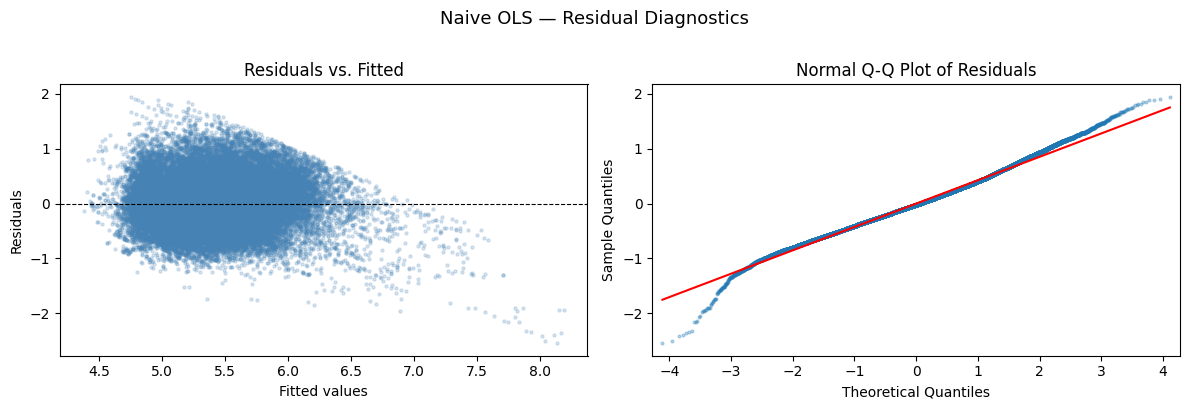

In [3]:
# --- Naive Multiple Linear Regression Baseline ---

# Target : logSum
# Features: city excluded, attr_index / rest_index (non-normalized) excluded
# Dummy variable treatment: room_type has 3 levels (apt, private, shared).
# Drop room_type_shared as the reference category

feature_cols = [
    "room_type_apt", "room_type_private",
    "person_capacity", "is_superhost", "multi", "biz",
    "cleanliness_rating", "guest_satisfaction_overall",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X = df[feature_cols].copy()
y = df["logSum"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# --- VIF to quantify multicollinearity ---
vif_data = {
    "Feature": feature_cols,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}

vif_df = (
    pd.DataFrame(vif_data)
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

# --- Residual diagnostics ---
fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Naive OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("naive_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
print("=== NAIVE OLS MODEL COEFFICIENTS ===")
print(model.summary().tables[1])

=== NAIVE OLS MODEL COEFFICIENTS ===
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          3.7522      0.033    115.422      0.000       3.689       3.816
room_type_apt                  0.6791      0.022     30.207      0.000       0.635       0.723
room_type_private              0.3588      0.023     15.786      0.000       0.314       0.403
person_capacity                0.0545      0.002     26.351      0.000       0.050       0.059
is_superhost                  -0.0569      0.005    -12.460      0.000      -0.066      -0.048
multi                         -0.0127      0.005     -2.642      0.008      -0.022      -0.003
biz                            0.0410      0.005      8.650      0.000       0.032       0.050
cleanliness_rating             0.0306      0.003     10.777      0.000       0.025       0.036
guest_satisfa

In [5]:
print("=== NAIVE OLS MODEL VARIANCE INFLATION FACTORS ===\n")
print(vif_df.to_string(index=False))

=== NAIVE OLS MODEL VARIANCE INFLATION FACTORS ===

                   Feature        VIF
guest_satisfaction_overall 207.547446
        cleanliness_rating 194.914337
             room_type_apt  48.820553
         room_type_private  28.262273
           person_capacity  13.537992
                  bedrooms   6.845875
                      dist   4.958058
           rest_index_norm   4.143421
           attr_index_norm   3.909315
                metro_dist   2.416861
                       biz   2.135414
                is_weekday   1.977420
                     multi   1.873652
              is_superhost   1.473536


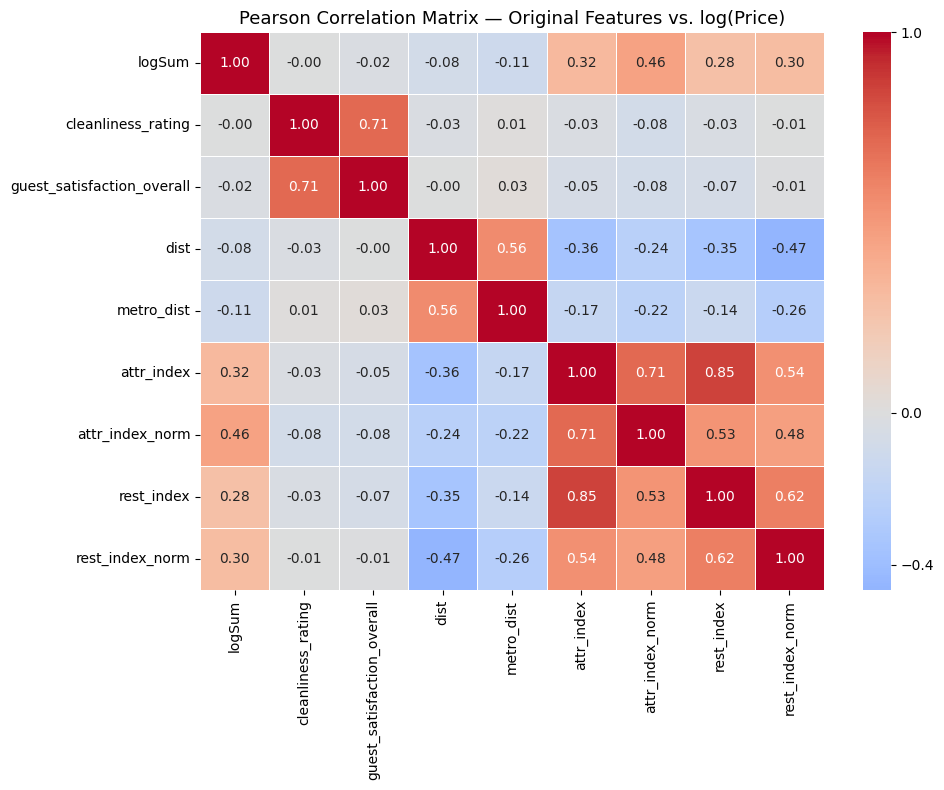

                              logSum
logSum                      1.000000
attr_index_norm             0.455700
attr_index                  0.319955
rest_index_norm             0.297390
rest_index                  0.279247
cleanliness_rating         -0.004160
guest_satisfaction_overall -0.022962
dist                       -0.081282
metro_dist                 -0.107059


In [6]:
# --- Correlation Matrix: Original Features ---

corr_cols_orig = [
    "logSum",
    "cleanliness_rating", "guest_satisfaction_overall",
    "dist", "metro_dist",
    "attr_index", "attr_index_norm",
    "rest_index", "rest_index_norm",
]

corr_matrix_orig = df[corr_cols_orig].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix_orig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.0, -0.4]},
)
ax.set_title("Pearson Correlation Matrix — Original Features vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_original.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix_orig[["logSum"]].sort_values("logSum", ascending=False).to_string())


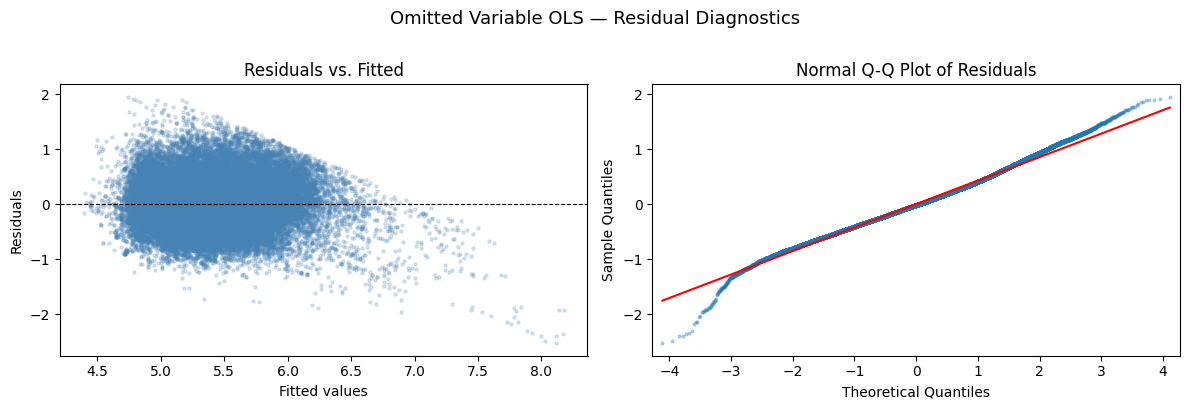

In [7]:
# --- Omitted Variable OLS ---

# drop cleanliness_rating and guest_satisfaction_overall as they are uncorrelated to logSum but highly correlated with each other
# All other specifications unchanged from the naive baseline.

feature_cols_omitted = [
    "room_type_apt", "room_type_private",
    "person_capacity", "is_superhost", "multi", "biz",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X_om = df[feature_cols_omitted].copy()
y = df["logSum"]

X_om_const = sm.add_constant(X_om)
model_omitted = sm.OLS(y, X_om_const).fit()

# --- VIF ---
vif_om = pd.DataFrame({
    "Feature": feature_cols_omitted,
    "VIF": [variance_inflation_factor(X_om.values, i) for i in range(X_om.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# --- Residual diagnostics ---
fitted_om = model_omitted.fittedvalues
residuals_om = model_omitted.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_om, residuals_om, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_om, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Omitted Variable OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("omitted_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
print("=== OMITTED OLS MODEL COEFFICIENTS ===")
print(model_omitted.summary().tables[1])

=== OMITTED OLS MODEL COEFFICIENTS ===
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.9286      0.024    162.402      0.000       3.881       3.976
room_type_apt         0.6876      0.023     30.558      0.000       0.643       0.732
room_type_private     0.3664      0.023     16.105      0.000       0.322       0.411
person_capacity       0.0538      0.002     26.007      0.000       0.050       0.058
is_superhost         -0.0457      0.004    -10.398      0.000      -0.054      -0.037
multi                -0.0129      0.005     -2.683      0.007      -0.022      -0.003
biz                   0.0400      0.005      8.599      0.000       0.031       0.049
bedrooms              0.1599      0.004     42.231      0.000       0.152       0.167
dist                  0.0467      0.001     43.840      0.000       0.045       0.049
metro_dist     

In [9]:
print("=== OMITTED OLS MODEL VARIANCE INFLATION FACTORS ===\n")
print(vif_om.to_string(index=False))

=== OMITTED OLS MODEL VARIANCE INFLATION FACTORS ===

          Feature       VIF
  person_capacity 13.314103
    room_type_apt 12.706643
         bedrooms  6.842079
room_type_private  6.683845
             dist  4.897299
  rest_index_norm  4.092234
  attr_index_norm  3.907682
       metro_dist  2.416669
              biz  2.098343
       is_weekday  1.974017
            multi  1.869031
     is_superhost  1.387782


In [10]:
# --- Model Comparison: Naive vs Omitted ---
print("=== MODEL COMPARISON ===\n")
print(f"{'Metric':<25} {'Naive OLS':>12} {'Omitted OLS':>13}")
print("-" * 52)
print(f"{'R²':<25} {model.rsquared:>12.4f} {model_omitted.rsquared:>13.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>12.4f} {model_omitted.rsquared_adj:>13.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>12.4f} {np.sqrt(model_omitted.mse_resid):>13.4f}")
print(f"{'AIC':<25} {model.aic:>12.2f} {model_omitted.aic:>13.2f}")
print(f"{'BIC':<25} {model.bic:>12.2f} {model_omitted.bic:>13.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>12.2f} {model_omitted.fvalue:>13.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>12d} {len(feature_cols_omitted):>13d}")

=== MODEL COMPARISON ===

Metric                       Naive OLS   Omitted OLS
----------------------------------------------------
R²                              0.4213        0.4197
Adj. R²                         0.4211        0.4196
RMSE                            0.4263        0.4269
AIC                           57987.59      58126.09
BIC                           58120.24      58241.05
F-statistic                    2661.08       3084.23
# predictors                        14            12


In [11]:
# --- PCA Composite for Satisfaction ---
# Motivation: the Naive OLS showed VIF ~195–207 for cleanliness_rating and
# guest_satisfaction_overall, and the Omitted OLS showed dropping them hurts fit.
# Solution: replace both with orthogonal PCA scores that retain all variance (VIF ≈ 1).

rating_cols = ["cleanliness_rating", "guest_satisfaction_overall"]
scaler = StandardScaler()
ratings_scaled = scaler.fit_transform(df[rating_cols])

pca_sat = PCA(n_components=2, random_state=42)
pc_scores = pca_sat.fit_transform(ratings_scaled)

print("Explained variance ratio per component:")
for i, evr in enumerate(pca_sat.explained_variance_ratio_, 1):
    print(f"  PC{i}: {evr:.3f}")
print(f"  Total: {pca_sat.explained_variance_ratio_.sum():.3f}")

print("\nLoadings:")
for i, comp in enumerate(pca_sat.components_, 1):
    print(f"  PC{i} — cleanliness_rating: {comp[0]:.3f}, "
          f"guest_satisfaction_overall: {comp[1]:.3f}")

# Insert satisfaction_pc1 and satisfaction_pc2 after guest_satisfaction_overall
insert_idx = df.columns.get_loc("guest_satisfaction_overall") + 1
df.insert(insert_idx,     "satisfaction_pc1", pc_scores[:, 0])
df.insert(insert_idx + 1, "satisfaction_pc2", pc_scores[:, 1])

print(f"\nColumns inserted at positions {insert_idx} and {insert_idx + 1}. df shape: {df.shape}")
df[["cleanliness_rating", "guest_satisfaction_overall", "satisfaction_pc1", "satisfaction_pc2"]].head()


Explained variance ratio per component:
  PC1: 0.856
  PC2: 0.144
  Total: 1.000

Loadings:
  PC1 — cleanliness_rating: 0.707, guest_satisfaction_overall: 0.707
  PC2 — cleanliness_rating: -0.707, guest_satisfaction_overall: 0.707

Columns inserted at positions 11 and 12. df shape: (51189, 22)


,cleanliness_rating,guest_satisfaction_overall,satisfaction_pc1,satisfaction_pc2
0,10.0,93.0,0.483801,-0.421538
1,8.0,85.0,-1.631521,0.428074
2,9.0,87.0,-0.732074,-0.154946
3,9.0,90.0,-0.494753,0.082375
4,10.0,98.0,0.879336,-0.026003


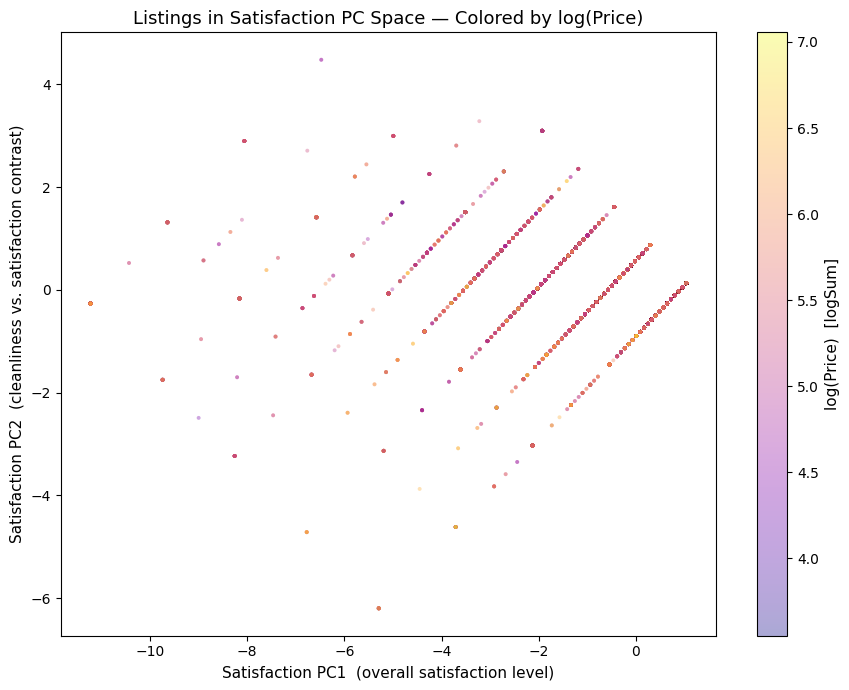

In [12]:
# --- Interpretation of PC Space: colored by log(Price) ---
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    df["satisfaction_pc1"],
    df["satisfaction_pc2"],
    c=df["logSum"],
    cmap="plasma",
    alpha=0.35,
    s=8,
    linewidths=0,
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log(Price)  [logSum]", fontsize=11)

ax.set_xlabel("Satisfaction PC1  (overall satisfaction level)", fontsize=11)
ax.set_ylabel("Satisfaction PC2  (cleanliness vs. satisfaction contrast)", fontsize=11)
ax.set_title("Listings in Satisfaction PC Space — Colored by log(Price)", fontsize=13)

plt.tight_layout()
plt.savefig("pca_scatter_logprice.png", dpi=300, bbox_inches="tight")
plt.show()


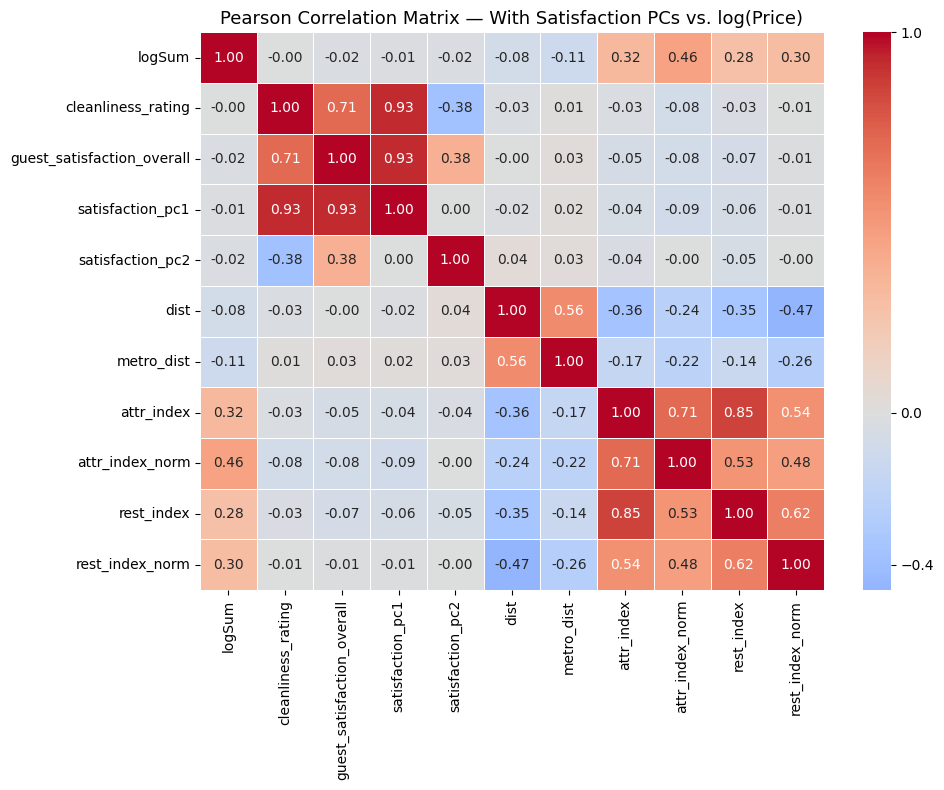

                              logSum
logSum                      1.000000
attr_index_norm             0.455700
attr_index                  0.319955
rest_index_norm             0.297390
rest_index                  0.279247
cleanliness_rating         -0.004160
satisfaction_pc1           -0.014654
guest_satisfaction_overall -0.022962
satisfaction_pc2           -0.024800
dist                       -0.081282
metro_dist                 -0.107059


In [13]:
# --- Correlation Matrix: transformed features ---
# cleanliness_rating + guest_satisfaction_overall replaced by satisfaction_pc1 + satisfaction_pc2

corr_cols = [
    "logSum",
    "cleanliness_rating", "guest_satisfaction_overall",
    "satisfaction_pc1", "satisfaction_pc2",
    "dist", "metro_dist",
    "attr_index", "attr_index_norm",
    "rest_index", "rest_index_norm",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.0, -0.4]},
)
ax.set_title("Pearson Correlation Matrix — With Satisfaction PCs vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_satisfaction_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print(corr_matrix[["logSum"]].sort_values("logSum", ascending=False).to_string())


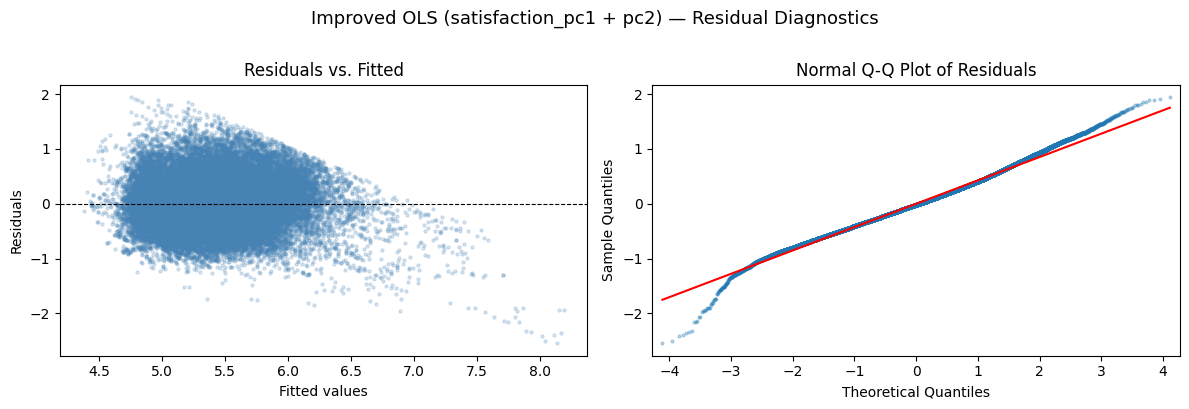

In [14]:
# --- Improved Multiple Linear Regression ---

# satisfaction_pc1 + satisfaction_pc2 replace cleanliness_rating + guest_satisfaction_overall.
# Both PCs are orthogonal (VIF ≈ 1.0 between them), preserving all original variance
# while eliminating the collinearity that distorted the naive model.

feature_cols_improved = [
    "room_type_apt", "room_type_private",
    "person_capacity", "is_superhost", "multi", "biz",
    "satisfaction_pc1", "satisfaction_pc2",
    "bedrooms", "dist", "metro_dist",
    "attr_index_norm", "rest_index_norm",
    "is_weekday",
]

X_imp = df[feature_cols_improved].copy()
y = df["logSum"]

X_imp_const = sm.add_constant(X_imp)
model_improved = sm.OLS(y, X_imp_const).fit()

# --- VIF ---
vif_imp = pd.DataFrame({
    "Feature": feature_cols_improved,
    "VIF": [variance_inflation_factor(X_imp.values, i) for i in range(X_imp.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# --- Residual diagnostics ---
fitted_imp = model_improved.fittedvalues
residuals_imp = model_improved.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_imp, residuals_imp, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_imp, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("Improved OLS (satisfaction_pc1 + pc2) — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("improved_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
print("=== IMPROVED OLS MODEL COEFFICIENTS ===")
print(model_improved.summary().tables[1])

=== IMPROVED OLS MODEL COEFFICIENTS ===
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.9356      0.024    162.857      0.000       3.888       3.983
room_type_apt         0.6791      0.022     30.207      0.000       0.635       0.723
room_type_private     0.3588      0.023     15.786      0.000       0.314       0.403
person_capacity       0.0545      0.002     26.351      0.000       0.050       0.059
is_superhost         -0.0569      0.005    -12.460      0.000      -0.066      -0.048
multi                -0.0127      0.005     -2.642      0.008      -0.022      -0.003
biz                   0.0410      0.005      8.650      0.000       0.032       0.050
satisfaction_pc1      0.0135      0.002      8.832      0.000       0.011       0.017
satisfaction_pc2     -0.0278      0.004     -7.821      0.000      -0.035      -0.021
bedrooms      

In [16]:
print("=== IMPROVED OLS MODEL VARIANCE INFLATION FACTORS ===\n")
print(vif_imp.to_string(index=False))

=== IMPROVED OLS MODEL VARIANCE INFLATION FACTORS ===

          Feature       VIF
  person_capacity 13.328231
    room_type_apt 12.719623
         bedrooms  6.849086
room_type_private  6.687763
             dist  4.905250
  rest_index_norm  4.094361
  attr_index_norm  3.922702
       metro_dist  2.417751
              biz  2.187385
       is_weekday  1.974068
            multi  1.878590
     is_superhost  1.505511
 satisfaction_pc1  1.134832
 satisfaction_pc2  1.022076


In [17]:
# --- Model comparison: Naive, Omitted, Improved ---
print("=== MODEL COMPARISON ===\n")
print(f"{'Metric':<25} {'Naive OLS':>12} {'Omitted OLS':>13} {'Improved OLS':>14}")
print("-" * 66)
print(f"{'R²':<25} {model.rsquared:>12.4f} {model_omitted.rsquared:>13.4f} {model_improved.rsquared:>14.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>12.4f} {model_omitted.rsquared_adj:>13.4f} {model_improved.rsquared_adj:>14.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>12.4f} {np.sqrt(model_omitted.mse_resid):>13.4f} {np.sqrt(model_improved.mse_resid):>14.4f}")
print(f"{'AIC':<25} {model.aic:>12.2f} {model_omitted.aic:>13.2f} {model_improved.aic:>14.2f}")
print(f"{'BIC':<25} {model.bic:>12.2f} {model_omitted.bic:>13.2f} {model_improved.bic:>14.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>12.2f} {model_omitted.fvalue:>13.2f} {model_improved.fvalue:>14.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>12d} {len(feature_cols_omitted):>13d} {len(feature_cols_improved):>14d}")

=== MODEL COMPARISON ===

Metric                       Naive OLS   Omitted OLS   Improved OLS
------------------------------------------------------------------
R²                              0.4213        0.4197         0.4213
Adj. R²                         0.4211        0.4196         0.4211
RMSE                            0.4263        0.4269         0.4263
AIC                           57987.59      58126.09       57987.59
BIC                           58120.24      58241.05       58120.24
F-statistic                    2661.08       3084.23        2661.08
# predictors                        14            12             14


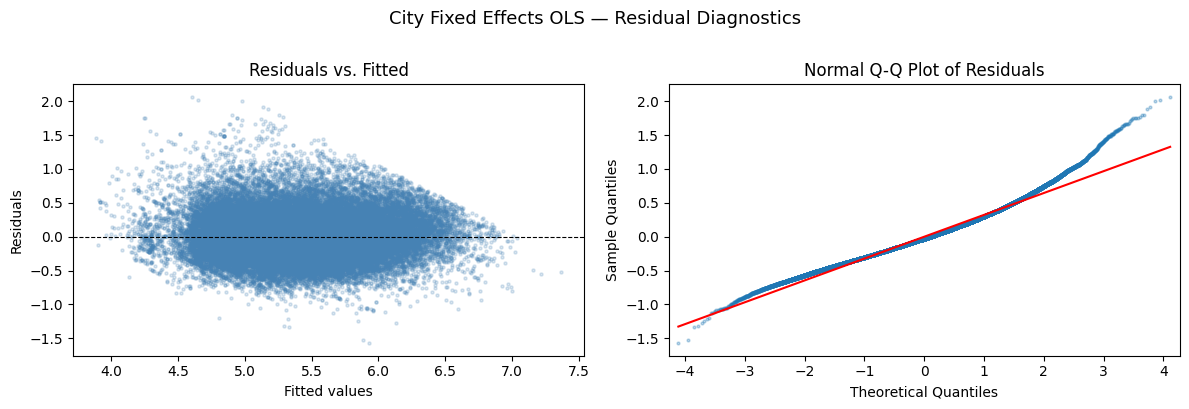

In [18]:
# --- City Fixed Effects OLS ---

# One-hot encode the city column (10 cities as 9 dummies).
# City 1 (Amsterdam) dropped as reference category.
# All other specifications identical to Improved OLS.

# city_2=Athens, city_3=Barcelona, ..., city_10=Vienna
city_dummies = pd.get_dummies(df["city"], prefix="city", drop_first=True).astype(int)


feature_cols_city = (
    ["room_type_apt", "room_type_private"]
    + ["person_capacity", "is_superhost", "multi", "biz"]
    + ["satisfaction_pc1", "satisfaction_pc2"]
    + ["bedrooms", "dist", "metro_dist"]
    + ["attr_index_norm", "rest_index_norm"]
    + ["is_weekday"]
    + list(city_dummies.columns)
)

X_city = pd.concat([df[feature_cols_city[:-9]], city_dummies], axis=1)
y = df["logSum"]

X_city_const = sm.add_constant(X_city)
model_city = sm.OLS(y, X_city_const).fit()

# --- VIF ---
vif_city = pd.DataFrame({
    "Feature": feature_cols_city,
    "VIF": [variance_inflation_factor(X_city.values, i) for i in range(X_city.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# --- Residual diagnostics ---
fitted_city = model_city.fittedvalues
residuals_city = model_city.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_city, residuals_city, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

sm.qqplot(residuals_city, line="s", ax=axes[1], alpha=0.3, markersize=2)
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.suptitle("City Fixed Effects OLS — Residual Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("city_fe_ols_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
print("=== CITY FIXED EFFECTS OLS MODEL COEFFICIENTS ===")
print(model_city.summary().tables[1])

=== CITY FIXED EFFECTS OLS MODEL COEFFICIENTS ===
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.9125      0.020    247.646      0.000       4.874       4.951
room_type_apt         0.8236      0.017     48.173      0.000       0.790       0.857
room_type_private     0.4060      0.017     23.506      0.000       0.372       0.440
person_capacity       0.0886      0.002     56.113      0.000       0.085       0.092
is_superhost          0.0229      0.003      6.534      0.000       0.016       0.030
multi                 0.0483      0.004     13.130      0.000       0.041       0.056
biz                   0.1159      0.004     31.149      0.000       0.109       0.123
satisfaction_pc1      0.0295      0.001     25.242      0.000       0.027       0.032
satisfaction_pc2     -0.0211      0.003     -7.805      0.000      -0.026      -0.016
bedr

In [20]:
print("=== CITY FIXED EFFECTS OLS MODEL VARIANCE INFLATION FACTORS ===\n")
print(vif_city.to_string(index=False))

=== CITY FIXED EFFECTS OLS MODEL VARIANCE INFLATION FACTORS ===

          Feature       VIF
    room_type_apt 26.109819
room_type_private 13.955201
  person_capacity 13.798097
             dist  9.288985
  rest_index_norm  9.071556
  attr_index_norm  8.971566
           city_7  7.638145
         bedrooms  6.988762
           city_9  5.337907
           city_8  4.720707
           city_6  3.958202
           city_2  3.877416
           city_5  3.032756
          city_10  2.876834
       metro_dist  2.730365
           city_4  2.460953
           city_3  2.396587
              biz  2.378061
       is_weekday  1.983149
            multi  1.937774
     is_superhost  1.541585
 satisfaction_pc1  1.147280
 satisfaction_pc2  1.029963


In [21]:
# --- Model comparison: Naive, Omitted, Improved, City FE ---
print("=== MODEL COMPARISON ===\n")
print(f"{'Metric':<25} {'Naive OLS':>11} {'Omitted OLS':>12} {'Improved OLS':>13} {'City FE OLS':>12}")
print("-" * 75)
print(f"{'R²':<25} {model.rsquared:>11.4f} {model_omitted.rsquared:>12.4f} {model_improved.rsquared:>13.4f} {model_city.rsquared:>12.4f}")
print(f"{'Adj. R²':<25} {model.rsquared_adj:>11.4f} {model_omitted.rsquared_adj:>12.4f} {model_improved.rsquared_adj:>13.4f} {model_city.rsquared_adj:>12.4f}")
print(f"{'RMSE':<25} {np.sqrt(model.mse_resid):>11.4f} {np.sqrt(model_omitted.mse_resid):>12.4f} {np.sqrt(model_improved.mse_resid):>13.4f} {np.sqrt(model_city.mse_resid):>12.4f}")
print(f"{'AIC':<25} {model.aic:>11.2f} {model_omitted.aic:>12.2f} {model_improved.aic:>13.2f} {model_city.aic:>12.2f}")
print(f"{'BIC':<25} {model.bic:>11.2f} {model_omitted.bic:>12.2f} {model_improved.bic:>13.2f} {model_city.bic:>12.2f}")
print(f"{'F-statistic':<25} {model.fvalue:>11.2f} {model_omitted.fvalue:>12.2f} {model_improved.fvalue:>13.2f} {model_city.fvalue:>12.2f}")
print(f"{'# predictors':<25} {len(feature_cols):>11d} {len(feature_cols_omitted):>12d} {len(feature_cols_improved):>13d} {len(feature_cols_city):>12d}")

=== MODEL COMPARISON ===

Metric                      Naive OLS  Omitted OLS  Improved OLS  City FE OLS
---------------------------------------------------------------------------
R²                             0.4213       0.4197        0.4213       0.6685
Adj. R²                        0.4211       0.4196        0.4211       0.6683
RMSE                           0.4263       0.4269        0.4263       0.3227
AIC                          57987.59     58126.09      57987.59     29492.04
BIC                          58120.24     58241.05      58120.24     29704.28
F-statistic                   2661.08      3084.23       2661.08      4485.15
# predictors                       14           12            14           23
